<div>
<img src="https://www.smu.edu.sg/themes/smubase_5g/assets/site-headers/logo-smu-d.svg?revised=20240229" width="200" align="center">
</div>

# Predicting Residential House Prices in Ames, Iowa
### ACCT682 Programming for Business Analytics — Team Project

**Group:** Topic 3 - House Prices

| Member Name | Student Number |
| --- | --- |
| *Andersen, Marius* | 01566259 |
| *Clarysse, Jelke* | 01576020 |
| *Xiao Wen, Fan* | 01577119 |
| *Kukreja, Siddharth Yash* | 01575731 |

**Instructor:** Dr Wang Jiwei  |  **Submitted:** August 2026

Runs end to end in about two minutes; the hyperparameter grids in sections 5.3 to 5.5 are the slow part. `train.csv` and `test.csv` sit in the same folder as this notebook, so every path is relative.


# 1. Introduction
### 1.1 The Business Problem
A house price depends on measurable things: size, quality, age, location, and features such as a garage or basement. Banks, insurers, tax assessors, buyers and sellers all need an estimate of what a house is worth before it is sold.
Estimating a price from recorded attributes is a regression problem. A model fitted to houses that have already sold can estimate the price of a house that has not.
This project predicts sale prices from 79 recorded attributes per house.

### 1.2 The Data
The data come from Ames, Iowa, and cover 2,919 residential sales between 2006 and 2010. They were compiled by De Cock (2011) and published by Kaggle as *House Prices - Advanced Regression Techniques*.

Each sale is described by 79 attributes, 43 categorical and 36 numeric. These cover lot and building size, quality and condition grades, year built and remodelled, neighbourhood, and features such as garages, basements and fireplaces.

The sales are split into 1,460 with the price recorded and 1,459 without. All our decisions are made on the 1,460 labelled sales; the remaining 1,459 are scored by Kaggle.

### 1.3 The metric 
Submissions are scored by the root mean squared error (RMSE) of the logarithm of the sale price. The logarithm makes the error proportional: a prediction 10% above the true price counts the same whether the house sold for 100,000 or 500,000. Without it, errors on expensive houses would dominate the score. We model log(SalePrice) directly and exponentiate the predictions before submission.
### 1.4 The structure of our report

**Section 2: Exploratory data analysis.** In this section we look at the distribution of the sale price, because its skew determines whether we model the price directly or its logarithm. We then examine the missing values to establish whether they are real gaps or recorded absences, since the two require different treatment. We look at the categorical columns to see how many levels they carry and whether any are ordered, and at the correlations between predictors, because predictors that duplicate one another affect the choice of model. We close by identifying two sales that do not reflect a normal transaction.

**Section 3: Data cleaning.** Here we apply five steps, each following from a finding in section 2. Because the findings in 2.2 and 2.3 point towards detailed treatment, we write the cleaning twice — once following the data dictionary in full, once with a single fill rule — and compare what each is worth.

**Section 4: Preprocessing pipeline.** In this section we scale the numeric columns and one-hot encode the categorical ones, inside a pipeline so that both are refitted on every training fold and cannot see the fold being scored. We also test whether the scaling is needed, since the tree models should be indifferent to it.

**Section 5: Models.** We fit ordinary least squares first, as the baseline the others have to beat, then Ridge and Lasso, a support vector regression, XGBoost, and gradient boosting with a Huber loss. All hyperparameters are chosen by 5-fold cross-validation on the same folds, so that the models remain comparable.

**Section 6: Evaluation.** In this section we compare the models against one another and against the leaderboard, and average four of them for an ensemble model. We then examine the residuals to check whether the errors are unbiased across the price range.

**Section 7: Kaggle submission.** Here we record every submission with the score it returned, because the leaderboard is the only measurement taken on houses we have not trained on, and build the final submission files.

**Section 8: Conclusion.** We set out what improved the score, what did not, and what we would try with more time.

### 1.5 Summary of Findings and Kaggle Score


Source: Kaggle, *House Prices - Advanced Regression Techniques*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, RidgeCV, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(f"train: {train.shape}, test: {test.shape}")
print(train.dtypes.value_counts())

train: (1460, 81), test: (1459, 80)
object     43
int64      35
float64     3
Name: count, dtype: int64


# 2. Exploratory Data Analysis

## 2.1 Sale Prices - The Dependent Variable

As shown in the figure below, sale prices are heavily right-skewed. This indicates that a small number of high-priced homes, well beyond the typical price range, are pulling the distribution to the right. In a skewed distribution, the mean and median diverge,the mean is pulled toward the extreme values, while the median remains a more representative measure of the “typical” home price.

This skew can create challenges for regression modelling. Many regression models are trained using squared-error loss, which penalizes large errors disproportionately more than small ones. As a result, the small number of high-priced homes can have a strong influence on the loss function, shifting the model’s focus away from the broader market and making it more sensitive to extreme values.

To address this, we applied a log transformation to sales price , reducing skewness from 1.88 to 0.12 and producing a much more symmetric distribution that may be better suited for modelling. This transformation reduces the relative influence of extreme prices and may support more reliable and generalizable predictions in future modelling.


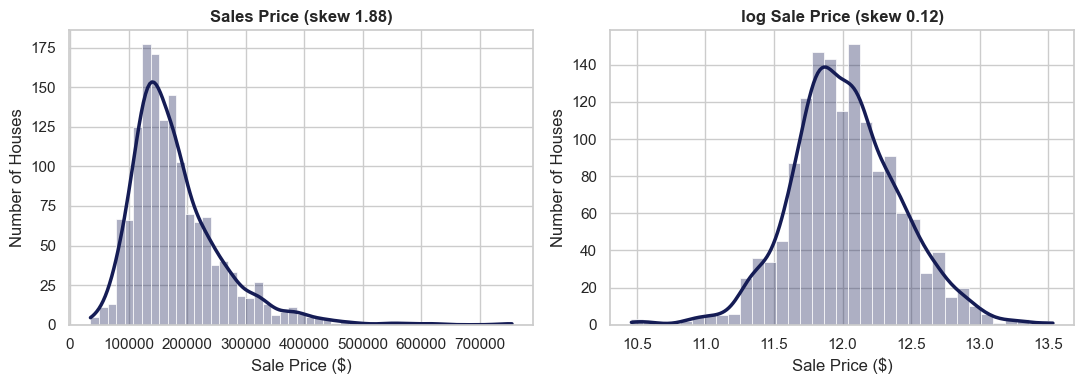

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train["SalePrice"], kde=True, color = "#151C55", alpha=0.35,  edgecolor="white", linewidth=0.5, ax=ax[0],  line_kws={"color": "#C69200", "linewidth": 2.5})
ax[0].set_title(f'Sales Price (skew {train["SalePrice"].skew():.2f})', fontsize=12, fontweight="bold")
ax[0].set_xlabel("Sale Price ($)")
ax[0].set_ylabel("Number of Houses")

sns.histplot(np.log(train["SalePrice"]), color = "#151C55", alpha=0.35,edgecolor="white", linewidth=0.5,line_kws={"color": "#C69200", "linewidth": 2.5}, kde=True, ax=ax[1])
ax[1].set_title(f'log Sale Price (skew {np.log(train["SalePrice"]).skew():.2f})', fontsize=12,  fontweight="bold")
ax[1].set_xlabel("Sale Price ($)")
ax[1].set_ylabel("Number of Houses")
plt.tight_layout()

## 2.2 Missing values

There are 34 columns with missing data. However, as shown in the figure below, the majority of these missing values represent the absence of a feature, such as a pool, garage, or fence, rather than a genuine data collection error. For example, a missing value in PoolQC simply indicates the property does not have a pool, and a missing value in GarageType indicates the property does not have a garage.

Given this, we treat most of these missing values as a meaningful category,  labeling them as "None" rather than imputing them statistically. Imputing these values would incorrectly suggest the feature exists but was unrecorded, when in fact the absence itself is informative and should be preserved as-is.

count    34.000000
mean     15.826331
std      31.314324
min       0.034258
25%       0.034258
50%       1.747174
75%       5.447071
max      99.657417
dtype: float64

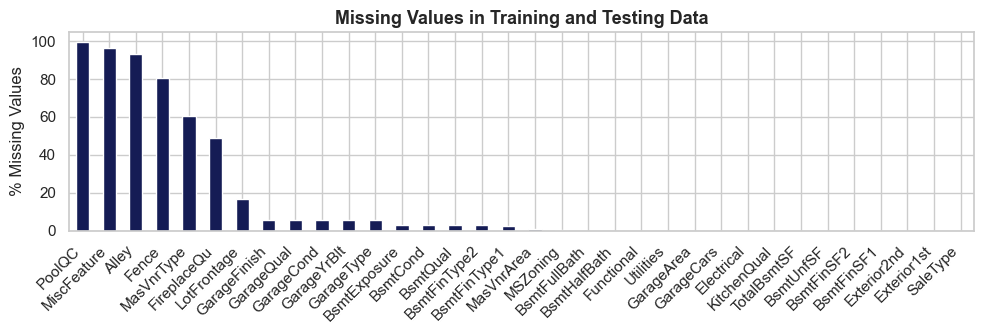

In [4]:
# train and test together, since test has gaps train does not
all_raw = pd.concat([train.drop(columns=["SalePrice"]), test], ignore_index=True)

missing = all_raw.isnull().sum()
missing = (missing[missing > 0] / len(all_raw) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 3.5))
missing.plot(kind="bar", color="#151C55")
plt.ylabel("% Missing Values")
plt.title("Missing Values in Training and Testing Data", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
missing.describe()

To confirm that missing values represent genuine absence rather than data collection errors, we cross-referenced the categorical column against its corresponding size/quantity feature (e.g. PoolQC vs. PoolArea). In each case, the count of blank entries closely matched the count of properties with a size value of zero. With only a small number of mismatches. This confirms these are structurally missing rather than randomly missing data, which supports our decision to encode them as "None" rather than statistically impute them. Thus, we fill these with `"None"` and the matching area columns with `0`.

In [5]:
# is a blank really "this house does not have one"? check against the matching size column
for cat, size in {"PoolQC": "PoolArea", "GarageType": "GarageArea", "BsmtQual": "TotalBsmtSF",
                  "FireplaceQu": "Fireplaces", "MasVnrType": "MasVnrArea"}.items():
    blank = all_raw[cat].isna()
    both = (blank & (all_raw[size].fillna(0) == 0)).sum()
    print(f"{cat:12s} blank: {blank.sum():5d}   of those with {size} = 0: {both:5d}")

PoolQC       blank:  2909   of those with PoolArea = 0:  2906
GarageType   blank:   157   of those with GarageArea = 0:   157
BsmtQual     blank:    81   of those with TotalBsmtSF = 0:    79
FireplaceQu  blank:  1420   of those with Fireplaces = 0:  1420
MasVnrType   blank:  1766   of those with MasVnrArea = 0:  1758


To check whether frontage is consistent across the dataset or varies by neighbourhood, we plot LotFrontage by neighbourhood and compare medians. The overall median is 68 feet, but neighbourhood medians range from 21 to 92 feet, filling every missing value with a single overall median would badly misrepresent streets on either end of that range. We therefore impute LotFrontage using the median of its own neighbourhood, rather than a single dataset-wide value, and use the median rather than the mean because lot sizes are right-skewed.

overall median 68, neighbourhood medians 21 to 92


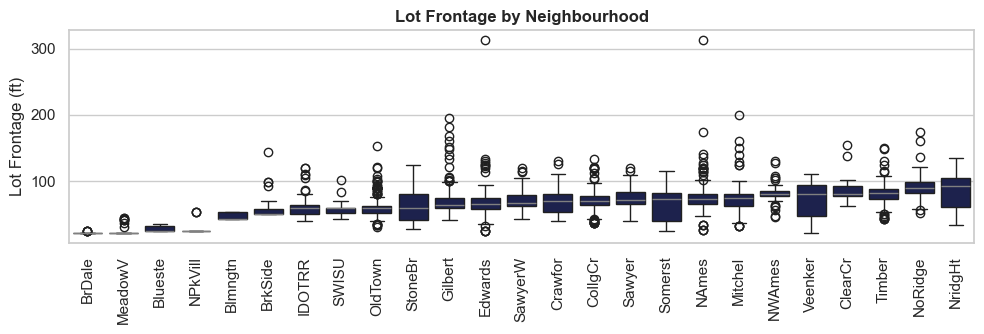

In [6]:
# LotFrontage is the one column where we have to guess a number
plt.figure(figsize=(10, 3.5))
order = all_raw.groupby("Neighborhood")["LotFrontage"].median().sort_values().index
sns.boxplot(data=all_raw, x="Neighborhood", y="LotFrontage", order=order, color="#151C55",  medianprops={"color": "grey", "linewidth": 1} )
plt.xticks(rotation=90); plt.title("Lot Frontage by Neighbourhood", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Lot Frontage (ft)")
plt.tight_layout()

nbhd = all_raw.groupby("Neighborhood")["LotFrontage"].median()
print(f"overall median {all_raw.LotFrontage.median():.0f}, neighbourhood medians {nbhd.min():.0f} to {nbhd.max():.0f}")

## 2.3 Categorical variables

Next, we explore the categorical columns in more detail. Of the 79 columns, 43 are categorical, and none has more than 25 levels, so one-hot encoding stays manageable rather than exploding into an unwieldy number of dummy variables.*

Neighborhood is the strongest categorical predictor of the group. The boxplot below spans a median price range from 88,000 to 315,000 depending on location alone. Several other categorical columns, like KitchenQual, carry a genuine order in their quality grades, as their medians show. In Section 3 we map those grades onto a numeric scale so the models can use the ordering, and leave the unordered columns to one-hot encoding.

*The KitchenQual medians confirm a genuine order*

In [7]:
# are the quality grades really ordered?
train.groupby("KitchenQual")["SalePrice"].median().sort_values().round(0)

KitchenQual
Fa    115000.0
TA    137000.0
Gd    201400.0
Ex    316750.0
Name: SalePrice, dtype: float64

*We check how many categorical columns there are and how many levels the widest one has, to see whether one-hot encoding stays practical.*

In [8]:
cats = all_raw.select_dtypes(include=[object])
print(f"{cats.shape[1]} categorical columns, at most {cats.nunique().max()} levels\n")
print(all_raw["Utilities"].value_counts(dropna=False))

43 categorical columns, at most 25 levels

Utilities
AllPub    2916
NaN          2
NoSeWa       1
Name: count, dtype: int64


`Utilities` has one non-`AllPub` house in the whole dataset, so it can only add noise. We drop it.

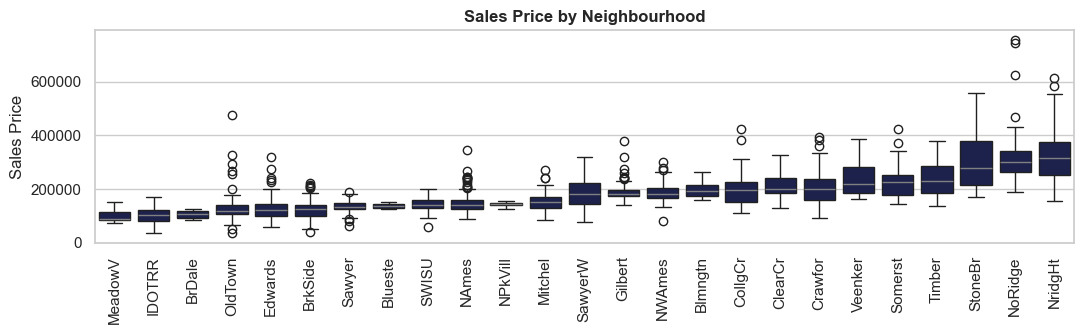

In [9]:
plt.figure(figsize=(11, 3.5))
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, color="#151C55",  medianprops={"color": "grey", "linewidth": 1})
plt.xticks(rotation=90); plt.title("Sales Price by Neighbourhood", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Sales Price")
plt.tight_layout()

## 2.4 Correlations

`OverallQual` (0.79) and `GrLivArea` (0.71) have the highest correlation with `SalePrice`, indicating that these variables are strong possible predictors. Garage size (`GarageCars` 0.64, `GarageArea` 0.62), basement/first-floor size, and bathroom/room counts follow at a moderate strength (0.5–0.6).

The heatmap also reveals several predictor pairs that are highly correlated with *each other*, not just with price: `GarageCars` and `GarageArea` (0.88), `TotalBsmtSF` and `1stFlrSF` (0.82), `GrLivArea` and `TotRmsAbvGrd` (0.83), and `YearBuilt` and `GarageYrBlt` (0.83). This overlap means several features carry largely redundant information, a form of multicollinearity that can destabilize coefficient estimates in linear models such as OLS, motivating the use of regularized approaches (Ridge, Lasso) later in the modelling stage.

SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486


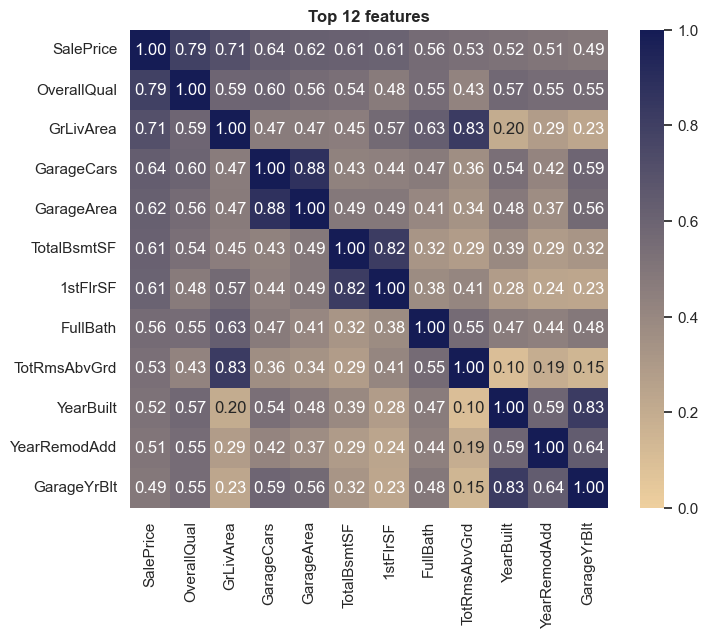

In [10]:
from matplotlib.colors import LinearSegmentedColormap

corr = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr.head(12).round(3).to_string())
top = corr.head(12).index

smu_branding = LinearSegmentedColormap.from_list(
    "brand_diverging",
    ["#C0392B", "#EFD09E", "#151C55"]  # red -> gold -> navy
)

plt.figure(figsize=(8, 6.5))
sns.heatmap(train[top].corr(), annot=True, fmt=".2f", cmap=smu_branding, center=0,vmin=0, square=True)
plt.title("Top 12 features",fontsize=12, fontweight="bold" ); plt.tight_layout()

In [11]:
# which predictors are near-duplicates of each other?
num = train.select_dtypes(include=[np.number]).drop(columns=["Id", "SalePrice"])
cm = num.corr().abs()
pairs = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool)).stack()
pairs[pairs > 0.8].sort_values(ascending=False).round(2)

GarageCars   GarageArea      0.88
YearBuilt    GarageYrBlt     0.83
GrLivArea    TotRmsAbvGrd    0.83
TotalBsmtSF  1stFlrSF        0.82
dtype: float64

Several predictors carry almost the same information. This is the reason plain OLS struggles later and the reason we reach for penalised regression: with near-duplicate columns the coefficients are barely identified, so they swing wildly between folds.

We therefore check the strongest predictors below.

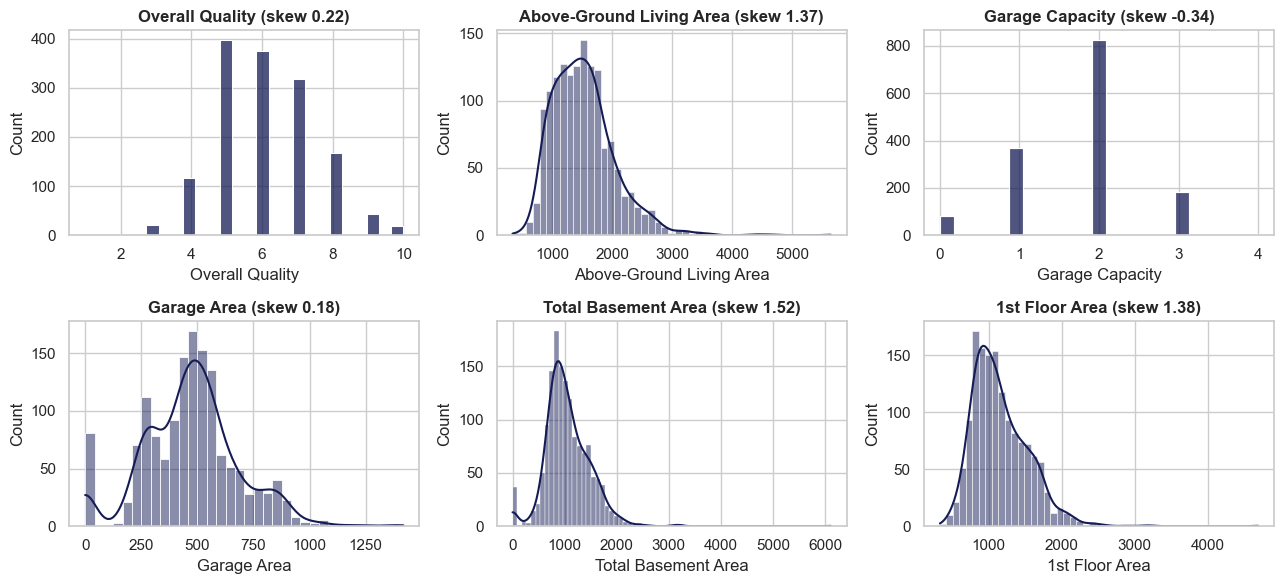

In [12]:
# distributions of the strongest numeric predictors
top6 = [c for c in corr.head(8).index if c != "SalePrice"][:6]

fig, ax = plt.subplots(2, 3, figsize=(13, 6))
for i, (a, col) in enumerate(zip(ax.ravel(), top6)):
    show_kde = i not in (0, 2)
    sns.histplot(train[col], kde=show_kde, ax=a, color = "#151C55")
    ax[0, 0].set_title(f"Overall Quality (skew {train['OverallQual'].skew():.2f})", fontweight="bold", fontsize=12)
ax[0, 1].set_title(f"Above-Ground Living Area (skew {train['GrLivArea'].skew():.2f})", fontweight="bold", fontsize=12)
ax[0, 2].set_title(f"Garage Capacity (skew {train['GarageCars'].skew():.2f})", fontweight="bold", fontsize=12)
ax[1, 0].set_title(f"Garage Area (skew {train['GarageArea'].skew():.2f})", fontweight="bold", fontsize=12)
ax[1, 1].set_title(f"Total Basement Area (skew {train['TotalBsmtSF'].skew():.2f})", fontweight="bold", fontsize=12)
ax[1, 2].set_title(f"1st Floor Area (skew {train['1stFlrSF'].skew():.2f})", fontweight="bold", fontsize=12)
# set each x-label individually
ax[0, 0].set_xlabel("Overall Quality")
ax[0, 1].set_xlabel("Above-Ground Living Area")
ax[0, 2].set_xlabel("Garage Capacity")
ax[1, 0].set_xlabel("Garage Area")
ax[1, 1].set_xlabel("Total Basement Area")
ax[1, 2].set_xlabel("1st Floor Area")
plt.tight_layout()

Several of the strongest predictors are themselves skewed, for the same reason `SalePrice` was: a small number of large or unusual properties stretch the distribution. `GrLivArea` (skew 1.37), `TotalBsmtSF` (1.52), and `1stFlrSF` (1.38) all show a similar right-skewed shape, so we log these in section 3 for the same reason we log the target: to stabilise variance and reduce the influence of extreme values on squared-error loss.

`OverallQual`, `GarageCars`, and `GarageArea` are close to symmetric already and are left as-is.

Additionally, the spikes at zero in `TotalBsmtSF` and `GarageArea` are houses that simply don't have a basement or garage, not missing or erroneous values, which is consistent with what we saw in section 2.2.

## 2.5 Outliers and leverage points

Four houses have `GrLivArea` above 4,000 sq ft. Two sold cheap (under $200,000) despite `OverallQual` of 10, both are `Partial` sales, meaning the house was sold before it was finished, so the price does not reflect a completed home. The other two sold for over $700,000, as expected for their size and quality (`Normal` and `Abnorml`).

We drop the two `Partial` sales (`GrLivArea > 4000` and `SalePrice < 300000`), and keep the two expensive ones.

De Cock (2011) adopt a similar approach to dealing with outliers.

We keep the other unusual sales, `Abnorml` and `Family`, because the test set contains these sale conditions too.

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
523,524,4676,184750,10,Partial
691,692,4316,755000,10,Normal
1182,1183,4476,745000,10,Abnorml
1298,1299,5642,160000,10,Partial


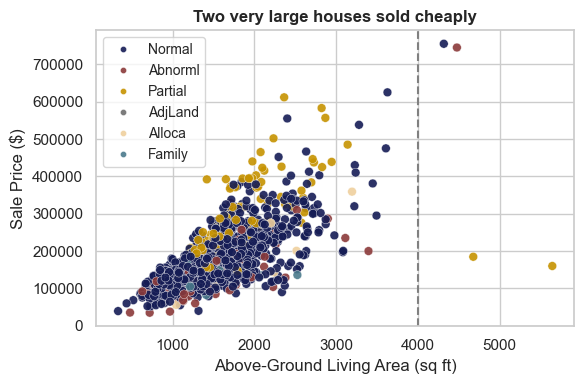

In [13]:
brand_palette = {
    "Normal":  "#151C55",  
    "Partial": "#C69200",  
    "Abnorml": "#8B3A3A",  
    "Family":  "#4A7A8C",  
    "Alloca":  "#EFD09E",  
    "AdjLand": "#6E6E6E",  
}
plt.figure(figsize=(6, 4))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", hue="SaleCondition", palette=brand_palette, s=40, alpha=0.9, edgecolor="white", linewidth=0.3 )
plt.axvline(4000, ls="--", c="grey")
plt.title("Two very large houses sold cheaply",  fontweight="bold", fontsize=12 )
plt.legend(loc="upper left", fontsize="small", markerscale=0.7)
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
train.loc[train.GrLivArea > 4000, ["Id", "GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]]

# 3. Data cleaning

Train and test are cleaned together so the same rules apply to both; the target is never involved, so nothing about `SalePrice` leaks.

1. **Drop the two partial sales** identified in 2.5 — `GrLivArea > 4000` and `SalePrice < 300000`. The two expensive large houses stay.
2. **Log the target.** 2.1 put the skew at 1.88, and 0.12 after logging. Everything from here on is modelled on `log(SalePrice)`.
3. **Drop `Utilities`.** One non-`AllPub` house in 2,919, so it carries no information (2.3).
4. **Fill each gap according to what it means.** In most of these columns a blank is an absent feature rather than a missing record. Quality grades map onto a 0 to 5 scale with 0 for "none", areas and counts such as `GarageArea` and `MasVnrArea` become 0, and unordered labels such as `GarageType` become `"None"`. Only the few cells that are genuinely missing, like the single `Electrical` value, take the median or the most common value.
5. **Log the skewed predictors.** 2.4 showed `GrLivArea`, `TotalBsmtSF` and `1stFlrSF` are skewed for the same reason the target was, so any numeric column with skew above 0.75 gets `log1p`. The threshold is measured on the training rows we keep, so the two dropped sales have no say in how the data is transformed.


In [14]:
outliers = train[(train.GrLivArea > 4000) & (train.SalePrice < 300000)].index
print(f"dropping Id {list(train.loc[outliers, 'Id'])}")

keep = ~train.index.isin(outliers)
y_all = np.log(train["SalePrice"])
ntrain = len(train)
all_data = pd.concat([train.drop(columns=["SalePrice"]), test], ignore_index=True)

dropping Id [524, 1299]


In [15]:
# almost constant
all_data = all_data.drop(columns=["Utilities"])

# stored as numbers but they are labels
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)
all_data["MoSold"] = all_data["MoSold"].astype(str)

# quality/condition columns share the same Ex-Gd-TA-Fa-Po scale. NA --> 0
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
qual_cols = ["PoolQC", "FireplaceQu", "GarageQual", "GarageCond", "BsmtQual", "BsmtCond",
             "ExterQual", "ExterCond", "HeatingQC", "KitchenQual"]

for c in qual_cols:
    all_data[c] = all_data[c].fillna("None").map(qual_map)

# two more ordered scales, each with their own NA-means-none bottom rung
finish_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
all_data["GarageFinish"] = all_data["GarageFinish"].fillna("None").map(finish_map)

exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
all_data["BsmtExposure"] = all_data["BsmtExposure"].fillna("None").map(exposure_map)

# remaining "NA means does not have one" columns - not ordered, stay categorical
none_cols = ["GarageType", "BsmtFinType1", "BsmtFinType2", "MasVnrType",
             "Alley", "Fence", "MiscFeature"]
zero_cols = ["PoolArea", "MiscVal", "Fireplaces",
             "GarageArea", "GarageCars", "GarageYrBlt",
             "TotalBsmtSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "BsmtFullBath", "BsmtHalfBath",
             "MasVnrArea"]

for c in none_cols:
    all_data[c] = all_data[c].fillna("None")
for c in zero_cols:
    all_data[c] = all_data[c].fillna(0)

ordinal_cols = qual_cols + ["GarageFinish", "BsmtExposure"]

# one rule for every remaining gap: median for numbers, most common value for labels
for c in all_data.columns:
    if c in none_cols + zero_cols + ordinal_cols:
        continue
    fill = all_data[c].median() if all_data[c].dtype != object else all_data[c].mode()[0]
    all_data[c] = all_data[c].fillna(fill)

print("remaining missing:", all_data.isnull().sum().sum())

remaining missing: 0


In [16]:
# several predictors are as skewed as the target was, so log them too
numeric = all_data.select_dtypes(include=[np.number]).columns.drop("Id")
numeric = numeric.drop(ordinal_cols)

# decide which columns from the training rows we are keeping -- the two sales we are
# about to discard should not get a say in how the data is transformed
skewed = all_data.iloc[:ntrain][keep][numeric].skew()
skewed = skewed[skewed > 0.75].index

all_data[skewed] = np.log1p(all_data[skewed])
print(f"log1p applied to {len(skewed)} columns")

log1p applied to 19 columns


# 4. Preprocessing pipeline

Two transformations are applied to the cleaned data, both inside a `Pipeline` so that they are refitted on each training fold rather than once on the full dataset.

Numeric columns are standardised. This is required by Lasso, Ridge and the support vector regression. The penalised regressions constrain the magnitude of their coefficients, so a column measured in square feet would be penalised on a different scale from one measured in rooms; the support vector regression computes distances across all columns simultaneously and is affected in the same way. The two tree models are unaffected, since a tree evaluates only which side of a threshold a value falls on, and standardisation preserves that ordering.

Categorical columns are one-hot encoded, giving each level its own binary column. The parameter `handle_unknown="ignore"` ensures that a level present in a validation fold but absent from the fold on which the encoder was fitted is encoded as zeros rather than raising an error. With the 21 quality columns retained as text in step 4, the resulting design matrix contains 279 columns derived from 79 original features.

Each model is wrapped by `make_pipe`, which supplies it with a clone of the preprocessor. A `Pipeline` fits its steps in place, so without cloning the models would share a single fitted encoder and the fold-level refitting would be lost.

The assumptions that XGBoost RMSE is insensitive to scaling and monotone log transforms was verified as a sanity check. The XGBoost model also performed better with the one-hot encoded variables, and hence the same dataset was used for all models. 

In [17]:
# the rows we are keeping, for looking houses up later
train_kept = train[keep].reset_index(drop=True)

X_all = all_data.iloc[:ntrain].drop(columns=["Id"]).reset_index(drop=True)
X_test = all_data.iloc[ntrain:].drop(columns=["Id"]).reset_index(drop=True)
test_ids = test["Id"].values

# now drop the two flagged sales
X = X_all[keep].reset_index(drop=True)
y = y_all[keep].reset_index(drop=True)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=[object]).columns.tolist()
print(f"{len(X)} rows, {len(numeric_features)} numeric and {len(categorical_features)} categorical columns")

1458 rows, 46 numeric and 32 categorical columns


In [18]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

# a Pipeline fits its steps in place, so every model gets its own copy
def make_pipe(model):
    return Pipeline([("pre", clone(preprocessor)), ("model", model)])

print("design matrix:", preprocessor.fit_transform(X).shape)

design matrix: (1458, 277)


# 5. Models
All model choices are made using the 1,458 training observations and evaluated through 5‑fold cross‑validation with the same folds throughout. This ensures comparability across models and avoids the overfitting risk of a single held‑out split: an earlier version tuned XGBoost against one 20% validation set, and the model it chose scored better in our own validation but 0.0009 worse on the leaderboard , a pattern that repeated in several decisions. The preprocessor defined in Section 4 is cloned for each model and refitted on every fold, so no information about a validation row leaks into its transformed predictors.

Out-of-sample scores are reported later through the RMSE scores attained through Kaggle. 

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model, X, y):
    oof = cross_val_predict(make_pipe(model), X, y, cv=kf)
    return np.sqrt(mean_squared_error(y, oof)), oof

## 5.1 Baseline: ordinary least squares

In [20]:
ols_rmse, ols_oof = cv_rmse(LinearRegression(), X, y)
print(f"OLS  CV RMSE = {ols_rmse:.4f}")
print(f"{preprocessor.fit_transform(X).shape[1]} columns fitted on {int(len(X) * 0.8)} rows per fold")

OLS  CV RMSE = 0.1329
277 columns fitted on 1166 rows per fold


OLS is the starting point and the worst model we fit. Strong collinearity among predictors causes coefficient estimates to swing widely between folds. For example, `GarageCars` and `GarageArea` correlate at 0.88, while `TotalBsmtSF` and `1stFlrSF` correlate at 0.82. The cross‑validated RMSE of 0.1329 serves as a baseline for a simple model.

## 5.2 Ridge and Lasso

Both shrink coefficients; the penalty strength `alpha` is chosen by internal cross-validation rather than by hand. Ridge keeps every column and pulls correlated ones together, Lasso sets weak coefficients to exactly zero and so doubles as feature selection.

In [21]:
ridge = RidgeCV(alphas=np.logspace(-2, 3, 100))
ridge_rmse, ridge_oof = cv_rmse(ridge, X, y)
print(f"Ridge  CV RMSE = {ridge_rmse:.4f}")

lasso = LassoCV(alphas=np.logspace(-4, -2, 20), max_iter=5000, random_state=RANDOM_STATE)
lasso_rmse, lasso_oof = cv_rmse(lasso, X, y)
print(f"Lasso  CV RMSE = {lasso_rmse:.4f}")

Ridge  CV RMSE = 0.1140
Lasso  CV RMSE = 0.1125


In [22]:
lasso_fit = make_pipe(lasso).fit(X, y)
lasso_coefs = lasso_fit.named_steps["model"].coef_
best_alpha = lasso_fit.named_steps["model"].alpha_

print(f"lasso alpha = {best_alpha:.5f}  ->  kept {(lasso_coefs != 0).sum()} of {len(lasso_coefs)} columns")

lasso alpha = 0.00055  ->  kept 102 of 277 columns


Both penalised regressions shrink coefficients toward zero. Ridge retains all 277 features and pulls correlated coefficients together; Lasso performs feature selection by setting weak coefficients to exactly zero. Their penalty strength alpha is chosen by internal cross‑validation within each fold, so no additional hold‑out set is needed.

On the full training set, Lasso selects the optimal alpha = 0.00055, retaining 102 of 277 columns. This demonstrates that automatic feature selection is effective; manual removal of correlated predictors is unnecessary because Lasso re‑decides which columns to keep inside every fold.

## 5.3 Support vector regression

`epsilon` is fixed at 0.01 — on the log scale that is a band of about 1% in price, finer than we could hope to predict. `C` and `gamma` are grid-searched on the same folds as everything else, over a range centred on where a first coarse sweep put the optimum.

Unlike OLS, which minimises squared error across every house, the epsilon‑support vector regression with an RBF kernel ignores observations already priced within an `epsilon`‑wide band and fits only to the points outside it. This makes it less sensitive to the unusual sales we deliberately kept in Section 2.5. The RBF kernel provides curvature, allowing the model to capture non‑linear relationships without specifying their form in advance.

The hyperparameter `C` controls the penalty applied to observations outside the `epsilon` band; higher `C` values force the model to fit those points more closely. `gamma` determines the local reach of the kernel: larger `gamma` values make the kernel more local, allowing the model to bend around individual data points. A grid search over `C ∈ {20, 30, 50}` and `gamma ∈ {0.0001, 0.0002, 0.0003, 0.0005}` identified `(C=50, gamma=0.0003)` as the optimal combination, achieving a CV RMSE of 0.1105.

We did not search beyond these ranges because preliminary coarse sweeps showed that pushing `C` to 300 or `gamma` to 0.001 produced clearly worse results and only slowed the search. At `C=300`, the model overfits to the few extreme observations, bending the decision surface too aggressively around outliers. At `gamma=0.001`, the kernel becomes so local that the model effectively memorises individual training points rather than learning general patterns - a classic overfitting signature that degrades cross‑validated performance. Neither extreme improved accuracy, and the additional computational cost was not justified.


In [23]:
svr_rows, svr_oofs = [], {}
for C in [20, 30, 50]:
    for gamma in [0.0001, 0.0002, 0.0003, 0.0005]:
        score, oof = cv_rmse(SVR(C=C, gamma=gamma, epsilon=0.01), X, y)
        svr_rows.append({"C": C, "gamma": gamma, "cv_rmse": score})
        svr_oofs[(C, gamma)] = oof

svr_grid = pd.DataFrame(svr_rows).sort_values("cv_rmse").reset_index(drop=True)
svr_grid.round(4)

,C,gamma,cv_rmse
0,50,0.0003,0.1105
1,30,0.0003,0.1109
2,20,0.0005,0.1109
3,30,0.0005,0.1111
4,50,0.0002,0.1111
5,20,0.0003,0.1119
6,50,0.0005,0.1122
7,30,0.0002,0.1124
8,20,0.0002,0.1131
9,50,0.0001,0.1134


In [24]:
best = svr_grid.iloc[0]
svr = SVR(C=int(best.C), gamma=best.gamma, epsilon=0.01)
svr_oof = svr_oofs[(int(best.C), best.gamma)]
svr_rmse = best.cv_rmse
print(f"chosen: C={int(best.C)}, gamma={best.gamma}  ->  CV RMSE = {svr_rmse:.4f}")

chosen: C=50, gamma=0.0003  ->  CV RMSE = 0.1105


## 5.4 XGBoost

Boosted trees, so no linearity assumption and interactions come for free. Depth is the setting that matters at this sample size — deeper trees memorise — so that is what we search. `subsample` and `colsample_bytree` are left at the usual values, which decorrelate the trees.

**Why a fixed tree count rather than early stopping?** We tried it: halting on a held-out slice made XGBoost worse and left gradient boosting unchanged. Early stopping needs 15% carved out of every training fold, and at 1,458 rows that costs more than the precision it adds.

In [25]:
xgb_rows, xgb_oofs = [], {}
for depth in [2, 3, 4]:
    model = XGBRegressor(max_depth=depth, n_estimators=1500, learning_rate=0.03,
                         min_child_weight=2, subsample=0.8, colsample_bytree=0.5,
                         random_state=RANDOM_STATE, n_jobs=4)
    score, oof = cv_rmse(model, X, y)
    xgb_rows.append({"max_depth": depth, "cv_rmse": score})
    xgb_oofs[depth] = (model, oof)

xgb_grid = pd.DataFrame(xgb_rows).sort_values("cv_rmse").reset_index(drop=True)
xgb_grid.round(4)

,max_depth,cv_rmse
0,3,0.1119
1,4,0.1139
2,2,0.1144


In [26]:
best_depth = int(xgb_grid.iloc[0].max_depth)
xgb, xgb_oof = xgb_oofs[best_depth]
xgb_rmse = xgb_grid.iloc[0].cv_rmse
print(f"chosen: depth {best_depth}  ->  CV RMSE = {xgb_rmse:.4f}")

chosen: depth 3  ->  CV RMSE = 0.1119


## 5.5 Gradient boosting with a Huber loss

A second tree model, chosen because the Huber loss fits the middle of the distribution and refuses to chase the far tail — the natural counterweight to the odd sales we deliberately kept in section 2.5.

In [27]:
gbr = GradientBoostingRegressor(
    n_estimators=1200, learning_rate=0.03, max_depth=3,
    max_features="sqrt", min_samples_leaf=5,
    loss="huber", random_state=RANDOM_STATE,
)
gbr_rmse, gbr_oof = cv_rmse(gbr, X, y)
print(f"GradientBoosting  CV RMSE = {gbr_rmse:.4f}")

GradientBoosting  CV RMSE = 0.1118


# 6. Evaluation

In [28]:
models = {"OLS": ols_oof,  "Lasso": lasso_oof,
          "SVR": svr_oof, "XGBoost": xgb_oof, "GradientBoosting": gbr_oof}

# scores Kaggle returned for each model submitted on its own, typed in from the
# leaderboard -- these are true out-of-sample, on 1,459 houses we never see
kaggle_lb = {"SVR": 0.12749, "Lasso": 0.12792, "XGBoost": 0.13055, "OLS": 0.13803, "GradientBoosting": 0.12724}


results = pd.DataFrame({"model": list(models),
                        "cv_rmse": [np.sqrt(mean_squared_error(y, p)) for p in models.values()]})
results["kaggle_lb"] = results.model.map(kaggle_lb)
results["gap"] = results.kaggle_lb - results.cv_rmse

# the leaderboard is the score that counts, so lead with it
results = results[["model", "kaggle_lb", "cv_rmse", "gap"]]
results.sort_values("kaggle_lb").round(4).reset_index(drop=True)

,model,kaggle_lb,cv_rmse,gap
0,GradientBoosting,0.1272,0.1118,0.0155
1,SVR,0.1275,0.1105,0.0170
2,Lasso,0.1279,0.1125,0.0154
3,XGBoost,0.1306,0.1119,0.0186
4,OLS,0.1380,0.1329,0.0052


`kaggle_lb` holds the score Kaggle returned for each model submitted on its own. SVR scores lowest on the leaderboard, and Lasso scores lowest on the Cross-Validation sample.

## 6.1 Averaging the models


We use equal weights to create a simple ensemble model:

| Variant | Kaggle LB | CV RMSE |
| --- | --- | --- |
| **Average of four** *(final)* | **0.12346** | 0.1062 |


The final blend combines four base models: Lasso, SVR, XGBoost, and the GradientBoosting regressor. We exclude OLS because it serves only as a baseline that all other models must surpass. Ridge is also excluded because Lasso outperforms it while the two are nearly identical in structure.

We assign equal weights to all four models in the blend. We tested alternative weights, but this appeared to be largely inconsequential. When we attempted to learn the weights from the data rather than setting them manually, the resulting values were near‑equal in any case, and the fitted weights performed worse on held‑out folds.

The ensemble performs better than any of the single models, because each model has its own strengths and weaknesses, and averaging cancels part of the error. 

**A neural network we tested and dropped.**
We also experimented with a multilayer perceptron neural network. This network had one hidden layer with 64 units and used weight decay chosen through cross‑validation. It achieved a cross‑validated RMSE of 0.1162 and a standalone leaderboard score of 0.12660.  We ultimately left the network out of the final submission because the additional code complexity was not justified for such a small gain.

In [29]:
picks = ["Lasso", "SVR", "XGBoost", "GradientBoosting"]

print("correlation between the models' errors:")
pd.DataFrame({m: y - models[m] for m in picks}).corr().round(2)

correlation between the models' errors:


,Lasso,SVR,XGBoost,GradientBoosting
Lasso,1.00,0.91,0.85,0.85
SVR,0.91,1.00,0.85,0.86
XGBoost,0.85,0.85,1.00,0.92
GradientBoosting,0.85,0.86,0.92,1.00


## 6.2 Residuals

The largest errors share clear patterns. The worst misses occur for houses sold under `Abnorml`, `Partial`, or `Family` sale conditions. These transactions are not arms-length or do not reflect fair market value. These cases are structurally different from normal sales. The model cannot price them accurately because the sale itself is anomalous. This is not a model failure. It is a limitation inherent to any model trained on market transactions when applied to non-market transactions.

R2 on the log scale     : 0.929
median error in dollars : 8,466


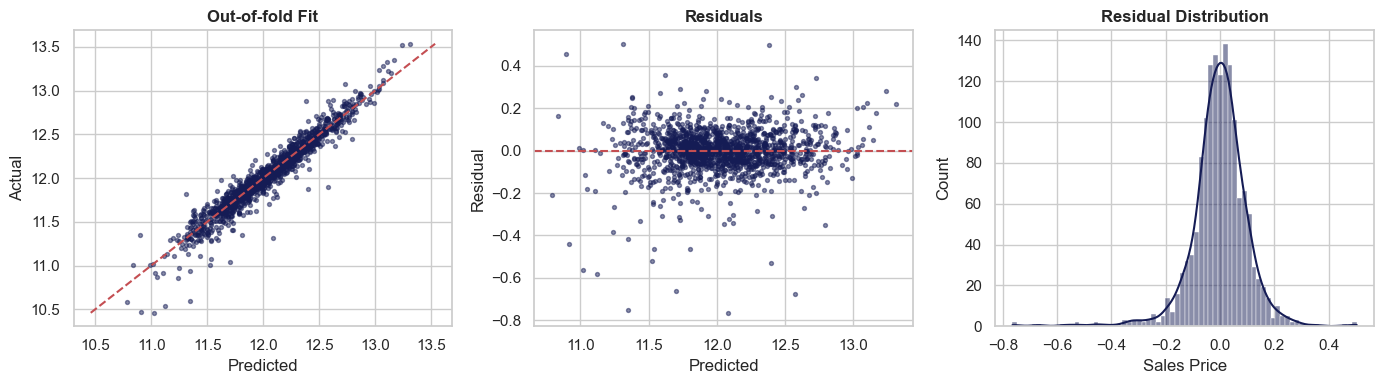

In [30]:
blend_oof = np.mean([models[m] for m in picks], axis=0)
blend_rmse = np.sqrt(mean_squared_error(y, blend_oof))

resid = y - blend_oof

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(blend_oof, y, s=8, alpha=0.5, color="#151C55")
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual"); ax[0].set_title("Out-of-fold Fit", fontweight="bold", fontsize=12)

ax[1].scatter(blend_oof, resid, s=8, alpha=0.5, color="#151C55"); ax[1].axhline(0, c="r", ls="--")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual"); ax[1].set_title("Residuals",  fontweight="bold", fontsize=12)

sns.histplot(resid, kde=True, ax=ax[2], color="#151C55"); ax[2].set_title("Residual Distribution", fontweight="bold", fontsize=12)
ax[2].set_xlabel("Sales Price")
plt.tight_layout()

print(f"R2 on the log scale     : {r2_score(y, blend_oof):.3f}")
print(f"median error in dollars : {np.median(np.abs(np.exp(y) - np.exp(blend_oof))):,.0f}")

In [31]:
worst = resid.abs().sort_values(ascending=False).head(8).index
train_kept.loc[worst, ["Id", "GrLivArea", "OverallQual", "SaleCondition", "SalePrice"]].assign(
    predicted=np.exp(blend_oof[worst]).round(0)
)

,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,predicted
631,633,1411,7,Family,82500,177208.0
30,31,1317,4,Normal,40000,84713.0
1322,1325,1795,8,Partial,147000,289367.0
462,463,864,5,Normal,62383,120646.0
967,969,968,3,Abnorml,37900,67790.0
495,496,720,4,Abnorml,34900,61170.0
587,589,1473,5,Partial,143000,242375.0
410,411,1276,5,Abnorml,60000,100900.0


## 6.4 What the models use

Both models rank `OverallQual` and `GrLivArea` as the two strongest predictors. Lasso's coefficients should not be interpreted literally. As shown in Section 2.4, the columns are collinear, so the attribution of an effect can shift among correlated variables. However, the agreement between such different model families on the top few predictors is reassuring. The signal carried by these features is strong enough to be detected by fundamentally different algorithms.


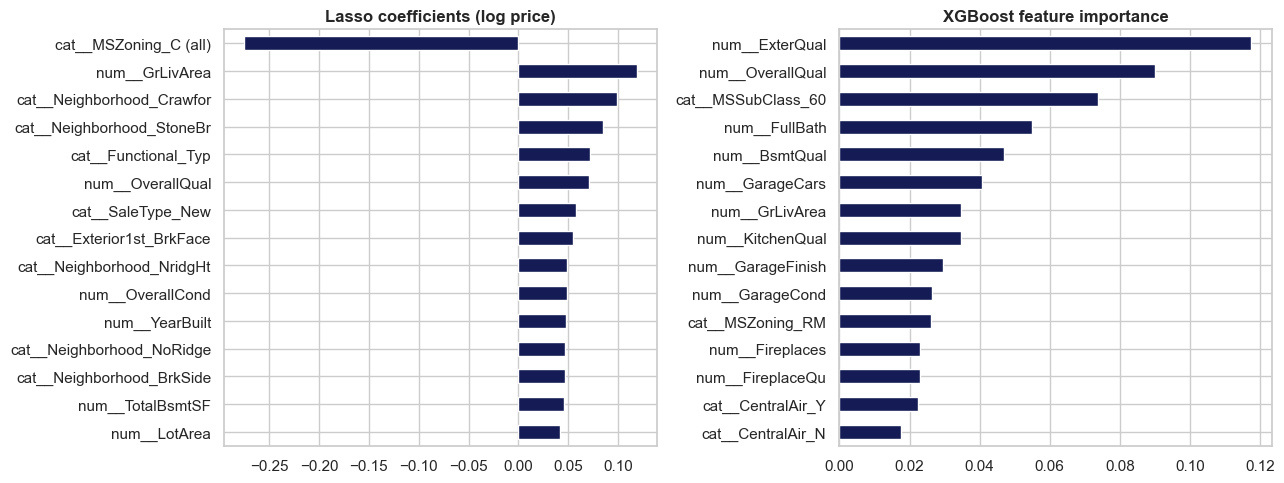

In [32]:
xgb_fit = make_pipe(xgb).fit(X, y)
names = lasso_fit.named_steps["pre"].get_feature_names_out()

lasso_top = pd.Series(lasso_coefs, index=names)
lasso_top = lasso_top[lasso_top != 0].sort_values(key=abs, ascending=False).head(15)
xgb_top = pd.Series(xgb_fit.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
lasso_top.iloc[::-1].plot(kind="barh", ax=ax[0], color="#151C55")
xgb_top.iloc[::-1].plot(kind="barh", ax=ax[1], color="#151C55")

ax[0].set_title("Lasso coefficients (log price)", fontweight="bold", fontsize=12)
ax[1].set_title("XGBoost feature importance", fontweight="bold", fontsize=12)

plt.tight_layout()

# 7. Conclusion

The final Kaggle public score is 0.12346, measured as RMSE on the log price scale. This corresponds to a median absolute error of approximately $8,466, meaning that half of our predictions fall within about eight thousand dollars of the actual sale price. This result places our model among the top public entries - 807 out of ~ 4000.

**What actually moved the needle.**

Three factors made a real difference. Tuning hyperparameters instead of using library defaults improved XGBoost substantially. Training the tree‑based models for a sufficient number of iterations was also critical; earlier submissions with fewer trees scored worse. Averaging models rather than choosing a single one delivered a confirmed improvement of 0.0038 on unseen data, since the best single model scored 0.12724.

**What we would do next.**

We would incorporate external neighbourhood‑level data, such as school quality, crime rates, or proximity to amenities. We would apply target encoding to categorical variables to compress the 32 categorical columns and reduce overfitting. We would replace the simple average with a stacked meta‑learner trained on cross‑validated predictions from the base models. We would also seek more data; this dataset is small by modern standards, and additional observations would improve every model we built.


**References**

- De Cock, D. (2011). Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project. *Journal of Statistics Education*, 19(3).
- Kaggle, *House Prices - Advanced Regression Techniques*.

In [33]:
ols_fit = make_pipe(LinearRegression()).fit(X, y)
svr_fit = make_pipe(svr).fit(X, y)
gbr_fit = make_pipe(gbr).fit(X, y)

test_preds = {"OLS": ols_fit.predict(X_test), "Lasso": lasso_fit.predict(X_test),
              "SVR": svr_fit.predict(X_test), "XGBoost": xgb_fit.predict(X_test),
              "GradientBoosting": gbr_fit.predict(X_test)}


cv = results.set_index("model").cv_rmse

# the equal average, and the hand-weighted alternative from section 6.1
blend = np.mean([test_preds[m] for m in picks], axis=0)

# each model on its own, as a control
filenames = {"OLS": "ols", "Lasso": "lasso", "SVR": "svr",
             "XGBoost": "xgboost", "GradientBoosting": "gbr"}

files = [("submission_blend.csv", blend, blend_rmse)]
for m, short in filenames.items():
    files.append((f"submission_{short}.csv", test_preds[m], cv[m]))

for name, pred, _ in files:
    pd.DataFrame({"Id": test_ids, "SalePrice": np.exp(pred)}).to_csv(name, index=False)

pd.DataFrame([{"file": n, "cv_rmse": score} for n, _, score in files]).round(4)

,file,cv_rmse
0,submission_blend.csv,0.1062
1,submission_ols.csv,0.1329
2,submission_lasso.csv,0.1125
3,submission_svr.csv,0.1105
4,submission_xgboost.csv,0.1119
5,submission_gbr.csv,0.1118


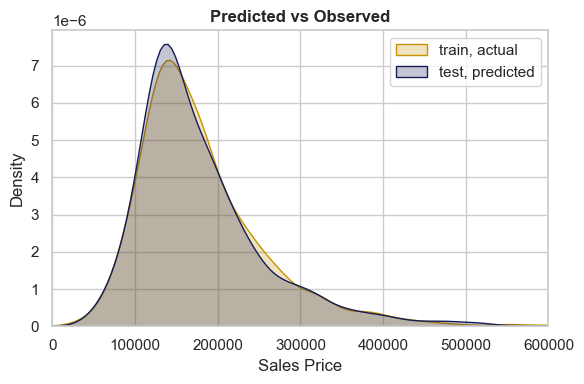

In [34]:
# sanity check: predicted prices should look like the prices we trained on
plt.figure(figsize=(6, 4))
sns.kdeplot(np.exp(y), label="train, actual", color="#C69200",fill=True)
sns.kdeplot(np.exp(blend), label="test, predicted",color="#151C55", fill=True)
plt.xlim(0, 600000); plt.xlabel("Sales Price"); plt.legend()
plt.title("Predicted vs Observed", fontweight="bold", fontsize=12); plt.tight_layout()